# H13 intergenic TPM prediction

Goal: train the final Elastic Net model on promoter motif features + TPM, then predict log2(TPM+1) values for intergenic regions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet

print("imports OK")


imports OK


In [2]:
promoter_file = Path("../data/processed/H13_promoters_651motifs_with_TPM.csv")
intergenic_file = Path("../promoter_TF_distance_weighted_H13_human_intergenic_power_x1_d500.csv")

promoter_df = pd.read_csv(promoter_file)
intergenic_df = pd.read_csv(intergenic_file)

promoter_df = promoter_df.dropna(subset=["log2_TPM_plus1"]).copy()

print("Promoter:", promoter_df.shape)
print("Intergenic:", intergenic_df.shape)

display(promoter_df.head())
display(intergenic_df.head())


Promoter: (20007, 654)
Intergenic: (20000, 652)


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A,gene_symbol,log2_TPM_plus1
0,gene-OR4F16|OR4F16|chr1:107876-117877|-,302.332236,17.941461,34.013831,164.797344,335.398194,3.790701,48.721730,144.299281,18.516320,...,12.155462,35.184567,2.758547,138.829016,0.365287,7.726213,36.682951,15.609821,OR4F16,0.150560
1,gene-SAMD11|SAMD11|chr1:348565-358566|+,19.340017,106.962620,0.704667,67.601283,58.273912,126.511248,105.848932,225.198969,111.177175,...,2.670962,179.830138,9.959176,266.290223,0.000000,95.240338,400.288574,121.867755,SAMD11,5.361768
2,gene-NOC2L|NOC2L|chr1:383040-393041|-,43.043277,110.551691,0.630066,64.879750,106.249774,163.746683,107.512710,195.744209,120.124106,...,2.299665,180.647134,3.405136,276.570075,0.246302,67.752125,311.213273,105.019855,NOC2L,7.795195
3,gene-KLHL17|KLHL17|chr1:384373-394374|+,24.091429,99.126770,1.826247,59.478485,72.509248,194.859057,106.007893,190.749799,121.381597,...,2.205529,204.674574,3.148192,278.045765,0.380648,68.033367,350.141791,129.096476,KLHL17,4.693766
4,gene-PLEKHN1|PLEKHN1|chr1:390192-400193|+,28.317637,139.136414,5.733277,80.299276,137.485214,166.712558,175.525151,308.016942,80.768011,...,12.315560,193.470044,28.377810,255.382943,0.246302,89.286750,318.594021,135.428670,PLEKHN1,0.000000


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC23.H13CORE.0.M.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
0,chr1:316720-326720,316.226463,44.409154,41.641048,101.421288,297.191814,19.193454,52.858850,163.070528,31.462869,...,5.200775,40.789557,8.673234,66.010690,4.894463,169.089859,0.0,41.846963,78.259130,31.350350
1,chr1:430252-440252,59.854380,73.976965,6.358749,60.720569,124.065969,103.307985,78.434293,213.703053,92.517493,...,2.076244,91.633290,1.519970,167.914141,12.109655,310.149758,0.0,120.256940,339.540111,107.213793
2,chr1:794097-804097,167.838635,108.989561,18.522978,58.369318,263.861656,44.528687,96.808322,261.191185,78.718146,...,2.541032,60.904225,8.853590,112.416145,15.943847,208.621756,0.0,62.867689,164.552040,59.864199
3,chr1:805756-815756,143.045976,78.858657,14.279440,54.885674,156.622881,59.082686,74.210017,220.839509,96.598795,...,10.111368,87.979054,3.582691,132.772655,3.050342,196.311311,0.0,64.770781,260.135134,78.486970
4,chr1:1019369-1029369,199.256162,83.287923,15.300426,47.162150,242.564876,35.242409,78.326811,182.417485,81.470554,...,1.159989,91.630385,10.156500,119.317282,10.217011,240.982179,0.0,44.714192,154.214204,78.097097


In [3]:
target_col = "log2_TPM_plus1"

exclude_cols = ["promoter_id", "gene_symbol", target_col]

feature_cols = [
    c for c in promoter_df.columns
    if c not in exclude_cols
]

X_promoter = promoter_df[feature_cols]
y_promoter = promoter_df[target_col]

X_intergenic = intergenic_df[feature_cols]

print("Promoter X:", X_promoter.shape)
print("Promoter y:", y_promoter.shape)
print("Intergenic X:", X_intergenic.shape)
print("Features:", len(feature_cols))


Promoter X: (20007, 651)
Promoter y: (20007,)
Intergenic X: (20000, 651)
Features: 651


## Train final Elastic Net model

Use the best parameters found in the promoter analysis notebook.


In [4]:
# Parameters from 02_H13_ElasticNet_analysis.ipynb
BEST_ALPHA = 0.006551285568595509
BEST_L1_RATIO = 0.9

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=BEST_ALPHA,
        l1_ratio=BEST_L1_RATIO,
        max_iter=50000,
        random_state=42
    ))
])

final_model.fit(X_promoter, y_promoter)

coef = final_model.named_steps["model"].coef_

print("Model trained")
print("Non-zero coefficients:", np.sum(coef != 0))


Model trained
Non-zero coefficients: 349


## Predict intergenic TPM

In [5]:
intergenic_pred_log2 = final_model.predict(X_intergenic)

intergenic_predictions = intergenic_df[["promoter_id"]].copy()
intergenic_predictions["predicted_log2_TPM_plus1"] = intergenic_pred_log2
intergenic_predictions["predicted_TPM"] = np.maximum(0, (2 ** intergenic_pred_log2) - 1)

display(intergenic_predictions.head())
display(intergenic_predictions["predicted_log2_TPM_plus1"].describe())
display(intergenic_predictions["predicted_TPM"].describe())


,promoter_id,predicted_log2_TPM_plus1,predicted_TPM
0,chr1:316720-326720,1.834872,2.567398
1,chr1:430252-440252,2.217652,3.651357
2,chr1:794097-804097,3.713980,12.122587
3,chr1:805756-815756,3.628185,11.364951
4,chr1:1019369-1029369,4.847378,27.787654


count    20000.000000
mean         0.615259
std          1.901757
min        -14.058324
25%         -0.201229
50%          0.493938
75%          1.225175
max         10.830093
Name: predicted_log2_TPM_plus1, dtype: float64

count    20000.000000
mean         7.661202
std         50.625512
min          0.000000
25%          0.000000
50%          0.408283
75%          1.337838
max       1819.466579
Name: predicted_TPM, dtype: float64

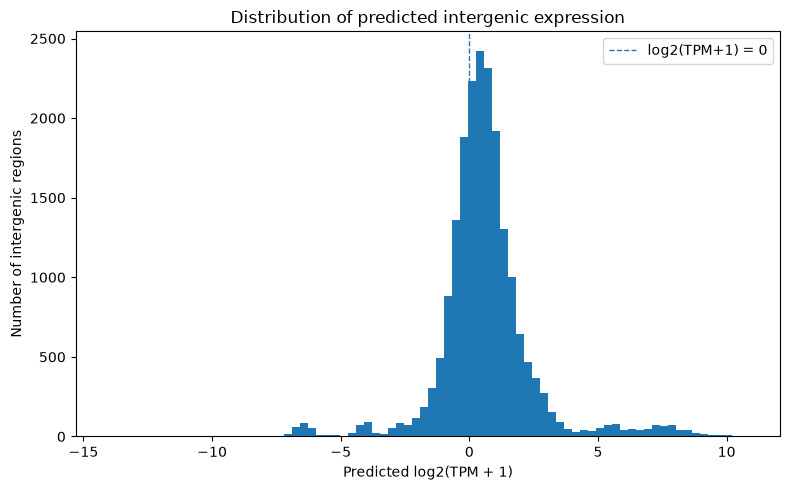

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    intergenic_predictions["predicted_log2_TPM_plus1"],
    bins=80
)

plt.axvline(0, linestyle="--", linewidth=1, label="log2(TPM+1) = 0")

plt.xlabel("Predicted log2(TPM + 1)")
plt.ylabel("Number of intergenic regions")
plt.title("Distribution of predicted intergenic expression")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
top_intergenic = intergenic_predictions.sort_values(
    "predicted_log2_TPM_plus1",
    ascending=False
).head(30)

display(top_intergenic)


,promoter_id,predicted_log2_TPM_plus1,predicted_TPM
13770,chr14:5561273-5571273,10.830093,1819.466579
13807,chr14:9109271-9119271,10.570034,1519.188066
17538,chr21:10248792-10258792,10.516881,1464.198594
18168,chrX:1610254-1620254,10.215353,1187.852018
17897,chr22:7822115-7832115,10.139660,1127.084595
13715,chr14:1384552-1394552,10.112175,1105.796938
13769,chr14:5551273-5561273,10.088344,1087.664561
13768,chr14:5511273-5521273,10.030119,1044.602848
13809,chr14:9149271-9159271,10.007604,1028.411232
13688,chr13:111539324-111549324,9.999048,1022.324504


## Compare promoter and intergenic prediction distributions

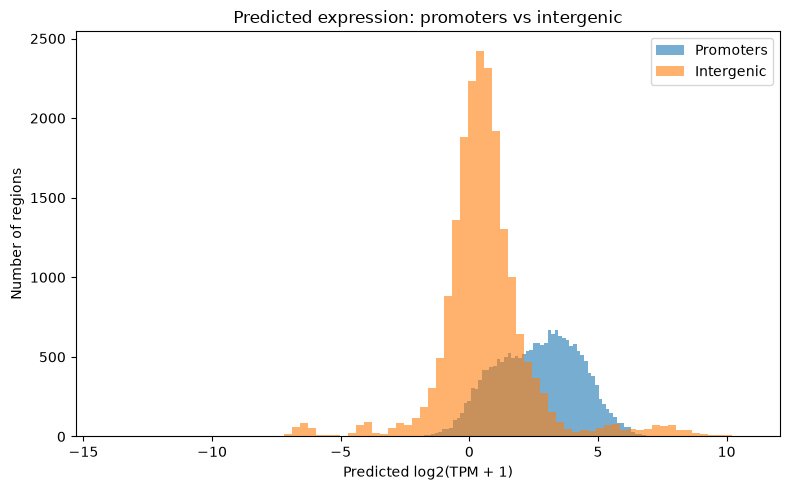

,promoter_predicted_log2,intergenic_predicted_log2
count,20007.000000,20000.000000
mean,2.675775,0.615259
std,1.613197,1.901757
min,-3.184310,-14.058324
25%,1.433404,-0.201229
50%,2.763860,0.493938
75%,3.897745,1.225175
max,8.133889,10.830093


In [8]:
promoter_pred_log2 = final_model.predict(X_promoter)

plt.figure(figsize=(8, 5))
plt.hist(promoter_pred_log2, bins=80, alpha=0.6, label="Promoters")
plt.hist(intergenic_pred_log2, bins=80, alpha=0.6, label="Intergenic")
plt.xlabel("Predicted log2(TPM + 1)")
plt.ylabel("Number of regions")
plt.title("Predicted expression: promoters vs intergenic")
plt.legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "promoter_predicted_log2": pd.Series(promoter_pred_log2).describe(),
    "intergenic_predicted_log2": pd.Series(intergenic_pred_log2).describe()
})

display(comparison)


In [22]:
from scipy.stats import ks_2samp

ks_stat, ks_p = ks_2samp(
    promoter_pred_log2,
    intergenic_pred_log2
)

print("Kolmogorov-Smirnov test: promoter vs intergenic predicted expression")
print("KS statistic:", ks_stat)
print("p-value:", ks_p)

Kolmogorov-Smirnov test: promoter vs intergenic predicted expression
KS statistic: 0.5458894636877093
p-value: 0.0


### The predicted expression distributions of promoters and intergenic regions differ significantly

## Save results

In [9]:
out_file = Path("../results/H13_intergenic_predicted_TPM.csv")

intergenic_predictions.to_csv(out_file, index=False)

print("Saved:", out_file)


Saved: ../results/H13_intergenic_predicted_TPM.csv


# plots

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [11]:
promoter_pca_df = promoter_df[["promoter_id"] + feature_cols].copy()
promoter_pca_df["region_type"] = "Promoter"

intergenic_pca_df = intergenic_df[["promoter_id"] + feature_cols].copy()
intergenic_pca_df["region_type"] = "Intergenic"

combined_df = pd.concat(
    [promoter_pca_df, intergenic_pca_df],
    axis=0,
    ignore_index=True
)

X_combined = combined_df[feature_cols]

print(combined_df.shape)

(40007, 653)


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

combined_df["PC1"] = pcs[:, 0]
combined_df["PC2"] = pcs[:, 1]

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.33640338 0.13238438]


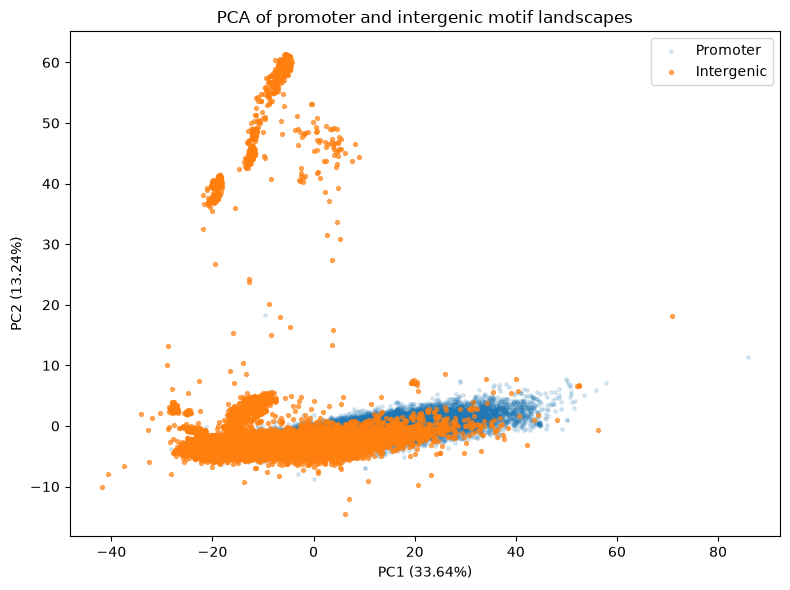

In [18]:
plt.figure(figsize=(8, 6))

prom = combined_df[combined_df["region_type"] == "Promoter"]
inter = combined_df[combined_df["region_type"] == "Intergenic"]

plt.scatter(
    prom["PC1"], prom["PC2"],
    s=6,
    alpha=0.15,
    label="Promoter"
)

plt.scatter(
    inter["PC1"], inter["PC2"],
    s=8,
    alpha=0.65,
    label="Intergenic"
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA of promoter and intergenic motif landscapes")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
promoter_pred_log2 = final_model.predict(X_promoter)
intergenic_pred_log2 = final_model.predict(X_intergenic)

combined_df["predicted_log2_TPM_plus1"] = np.concatenate([
    promoter_pred_log2,
    intergenic_pred_log2
])

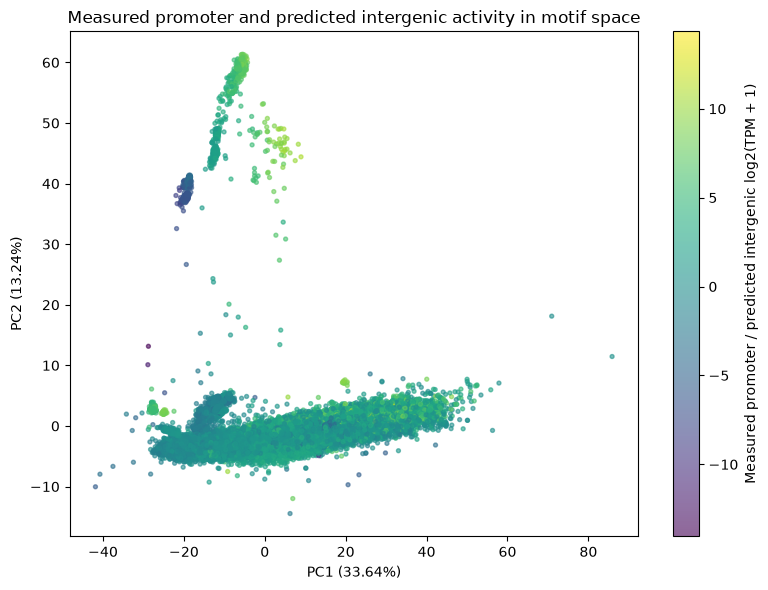

In [25]:
combined_df["expression_for_color"] = np.nan

combined_df.loc[
    combined_df["region_type"] == "Promoter",
    "expression_for_color"
] = promoter_df["log2_TPM_plus1"].values

combined_df.loc[
    combined_df["region_type"] == "Intergenic",
    "expression_for_color"
] = intergenic_pred_log2

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    combined_df["PC1"],
    combined_df["PC2"],
    c=combined_df["expression_for_color"],
    s=8,
    alpha=0.6
)

plt.colorbar(scatter, label="Measured promoter / predicted intergenic log2(TPM + 1)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Measured promoter and predicted intergenic activity in motif space")
plt.tight_layout()
plt.show()

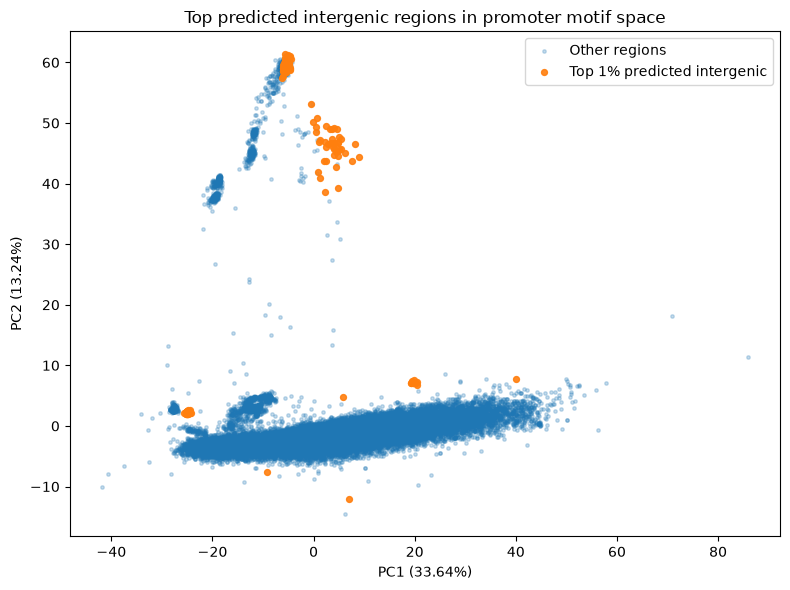

Top predicted intergenic threshold: 7.7531454913133215
Number highlighted: 200


In [16]:
threshold = intergenic_predictions["predicted_log2_TPM_plus1"].quantile(0.99)

top_intergenic_ids = set(
    intergenic_predictions.loc[
        intergenic_predictions["predicted_log2_TPM_plus1"] >= threshold,
        "promoter_id"
    ]
)

combined_df["top_predicted_intergenic"] = (
    (combined_df["region_type"] == "Intergenic") &
    (combined_df["promoter_id"].isin(top_intergenic_ids))
)

plt.figure(figsize=(8, 6))

background = combined_df[~combined_df["top_predicted_intergenic"]]
highlight = combined_df[combined_df["top_predicted_intergenic"]]

plt.scatter(
    background["PC1"],
    background["PC2"],
    s=6,
    alpha=0.25,
    label="Other regions"
)

plt.scatter(
    highlight["PC1"],
    highlight["PC2"],
    s=18,
    alpha=0.9,
    label="Top 1% predicted intergenic"
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Top predicted intergenic regions in promoter motif space")
plt.legend()
plt.tight_layout()
plt.show()

print("Top predicted intergenic threshold:", threshold)
print("Number highlighted:", len(highlight))

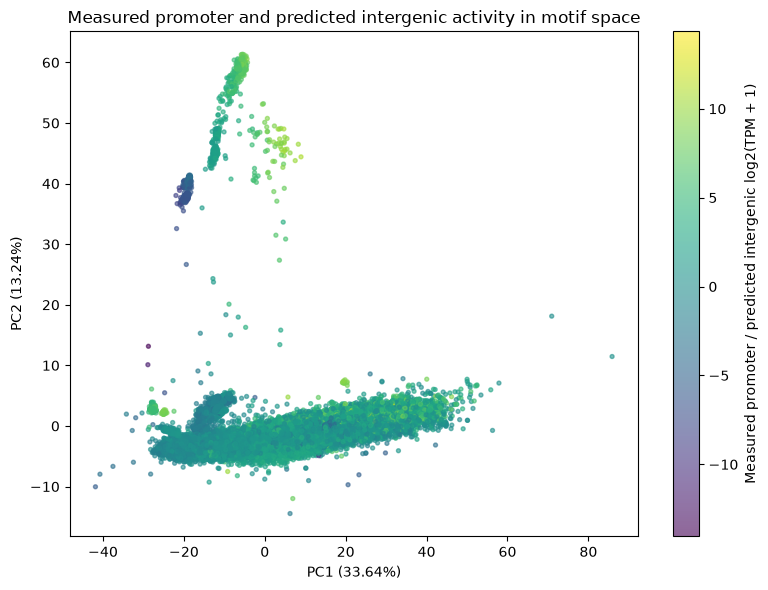

In [20]:
combined_df["expression_for_color"] = np.nan

combined_df.loc[
    combined_df["region_type"] == "Promoter",
    "expression_for_color"
] = promoter_df["log2_TPM_plus1"].values

combined_df.loc[
    combined_df["region_type"] == "Intergenic",
    "expression_for_color"
] = intergenic_pred_log2

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    combined_df["PC1"],
    combined_df["PC2"],
    c=combined_df["expression_for_color"],
    s=8,
    alpha=0.6
)

plt.colorbar(scatter, label="Measured promoter / predicted intergenic log2(TPM + 1)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Measured promoter and predicted intergenic activity in motif space")
plt.tight_layout()
plt.show()

In [ ]:
combined_df.to_csv(
    "../results/H13_promoter_intergenic_PCA_predictions.csv",
    index=False
)

In [23]:
plt.savefig("../figures/FIGURE_NAME.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>